# **Tumor Detection**

## **Data Discovery**

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, color, transform, feature

### **Data Dimensions**

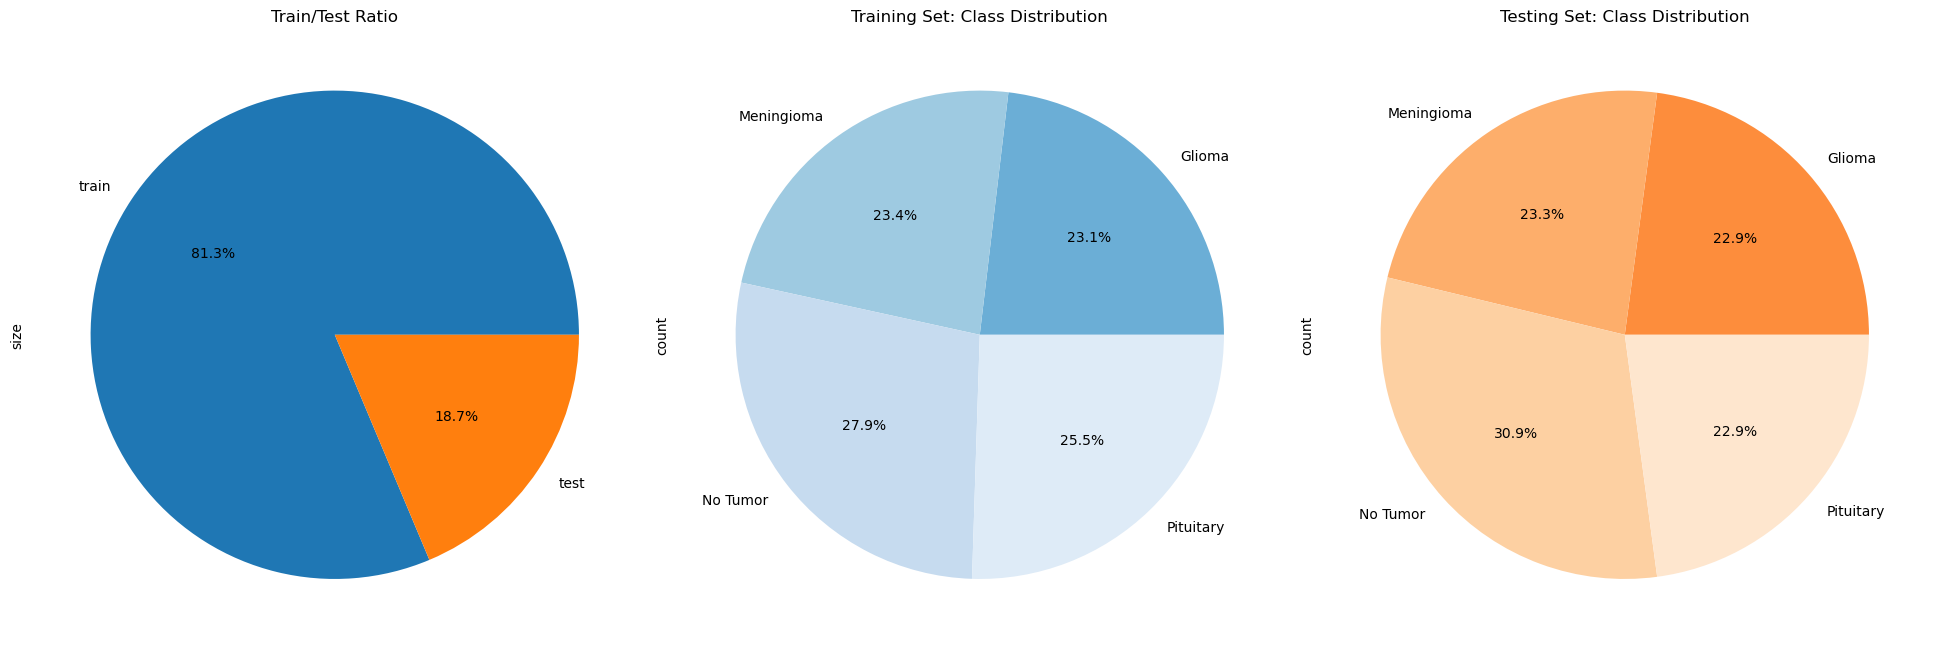

In [43]:
from _data import load_brain_tumor_1d
from matplotlib.colors import LinearSegmentedColormap

train, test = load_brain_tumor_1d(
    include_raw=True, include_hog=True, include_lbp=True, pca_mode="local"
)

fig, axes = plt.subplots(1, 3, figsize=(19.5, 6.5))

# Train/Test Ratio
pd.DataFrame(
    [train.shape[0], test.shape[0]], index=["train", "test"], columns=["size"]
).plot.pie(
    y="size", autopct="%1.1f%%", legend=False, title="Train/Test Ratio", ax=axes[0]
)

# Training Set: Class Distribution
train_labels = pd.DataFrame(train).iloc[:, -1].astype(int).value_counts().sort_index()
train_labels.index = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
train_labels.plot.pie(
    autopct="%1.1f%%",
    cmap=LinearSegmentedColormap.from_list("train_color", ["#6baed6", "#9ecae1", "#c6dbef", "#deebf7"]),
    title="Training Set: Class Distribution",
    ax=axes[1],
)

# Testing Set: Class Distribution
test_labels = pd.DataFrame(test).iloc[:, -1].astype(int).value_counts().sort_index()
test_labels.index = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
test_labels.plot.pie(
    autopct="%1.1f%%",
    cmap=LinearSegmentedColormap.from_list("test_color", ["#fd8d3c", "#fdae6b", "#fdd0a2", "#fee6ce"]),
    title="Testing Set: Class Distribution",
    ax=axes[2],
)

plt.tight_layout()
plt.show()

### **Extracting HOG and LBP on Normal, Pneumonia(Bacteria), and Pneumonia(Virus) Images**

In [44]:
def crop_brain_region(image, threshold=10):
    """
    Crop image to focus on brain region by removing black borders.
    """
    # Create binary mask where brain tissue exists
    mask = image > threshold
    
    # Find coordinates where brain exists
    coords = np.argwhere(mask)
    
    if len(coords) == 0:
        return image  # Return original if no brain detected
    
    # Get bounding box
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    # Add small padding
    padding = 5
    y_min = max(0, y_min - padding)
    x_min = max(0, x_min - padding)
    y_max = min(image.shape[0], y_max + padding)
    x_max = min(image.shape[1], x_max + padding)
    
    # Crop and resize back to target size
    cropped = image[y_min:y_max, x_min:x_max]
    
    return cropped

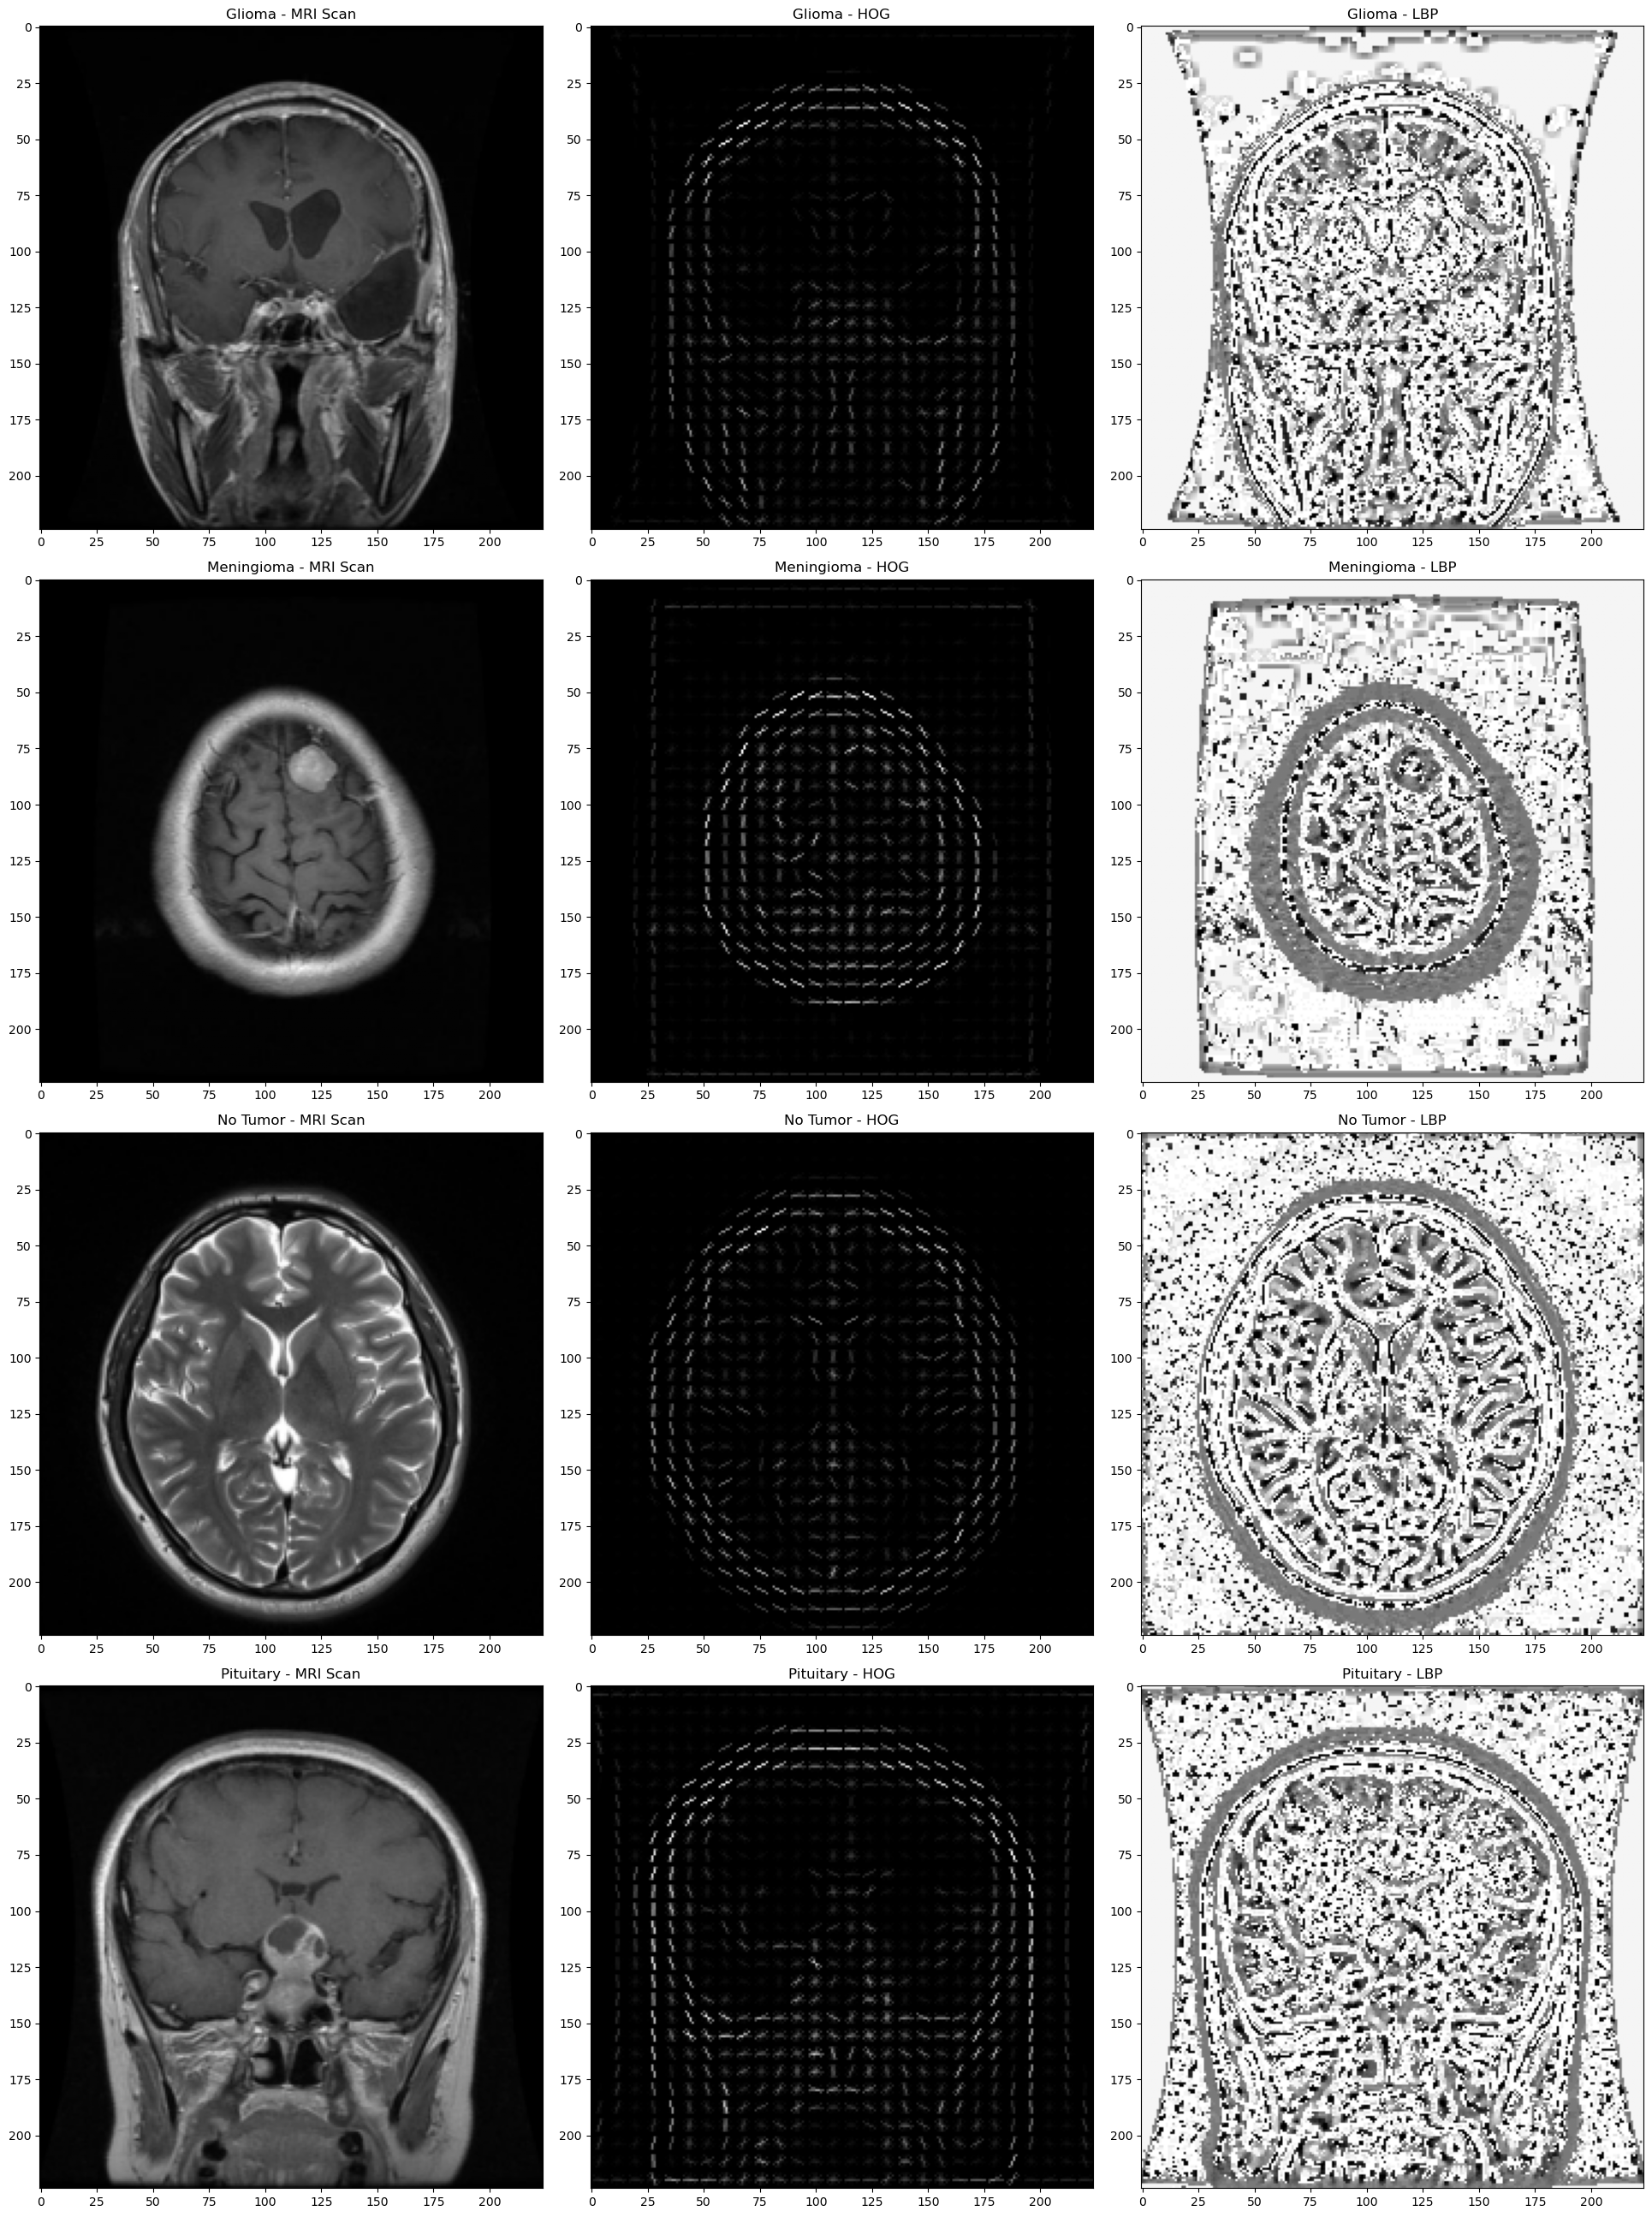

In [45]:
picked_images = [
  {
    "category": "Glioma",
    "filepath": "./data/Training/glioma/Tr-gl_0011.jpg",
  },
  {
    "category": "Meningioma",
    "filepath": "./data/Training/meningioma/Tr-me_0015.jpg",
  },
  {
    "category": "No Tumor",
    "filepath": "./data/Training/notumor/Tr-no_0015.jpg",
  },
  {
    "category": "Pituitary",
    "filepath": "./data/Training/pituitary/Tr-pi_0011.jpg",
  }
]

fig, axes = plt.subplots(
  len(picked_images), 3, figsize=(19.5, 6.5 * len(picked_images))
)
ax = axes.ravel()

for index, image in enumerate(picked_images):
  image_file = io.imread(image["filepath"])
  if len(image_file.shape) == 3:
    image_file = color.rgb2gray(image_file)
  

  # if I want to cropped..
  # image_cropped = crop_brain_region(image_file, threshold=0.1)
  # image_resized = transform.resize(image_cropped, (224, 224), preserve_range=True)

  image_resized = transform.resize(image_file, (224, 224), preserve_range=True)

  # Convert properly to uint8 FIRST
  image_uint8 = (image_resized * 255).astype(np.uint8) if image_resized.max() <= 1.0 else image_resized.astype(np.uint8)

  feature_hog, image_hog = feature.hog(
    image_resized,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    transform_sqrt=True,
    feature_vector=True,
    visualize=True,
  )
  image_lbp = feature.local_binary_pattern(
    image_uint8.astype(np.uint8), 24, 3, "uniform"
  )

  ax[index * 3 + 0].imshow(image_resized, cmap="gray")
  ax[index * 3 + 0].set_title(f"{image['category']} - MRI Scan")
  ax[index * 3 + 1].imshow(image_hog, cmap="gray")
  ax[index * 3 + 1].set_title(f"{image['category']} - HOG")
  ax[index * 3 + 2].imshow(image_lbp, cmap="gray")
  ax[index * 3 + 2].set_title(f"{image['category']} - LBP")

plt.tight_layout()
plt.show()

### **Applying PCA on a Combination of Original, HOG and LBP features**

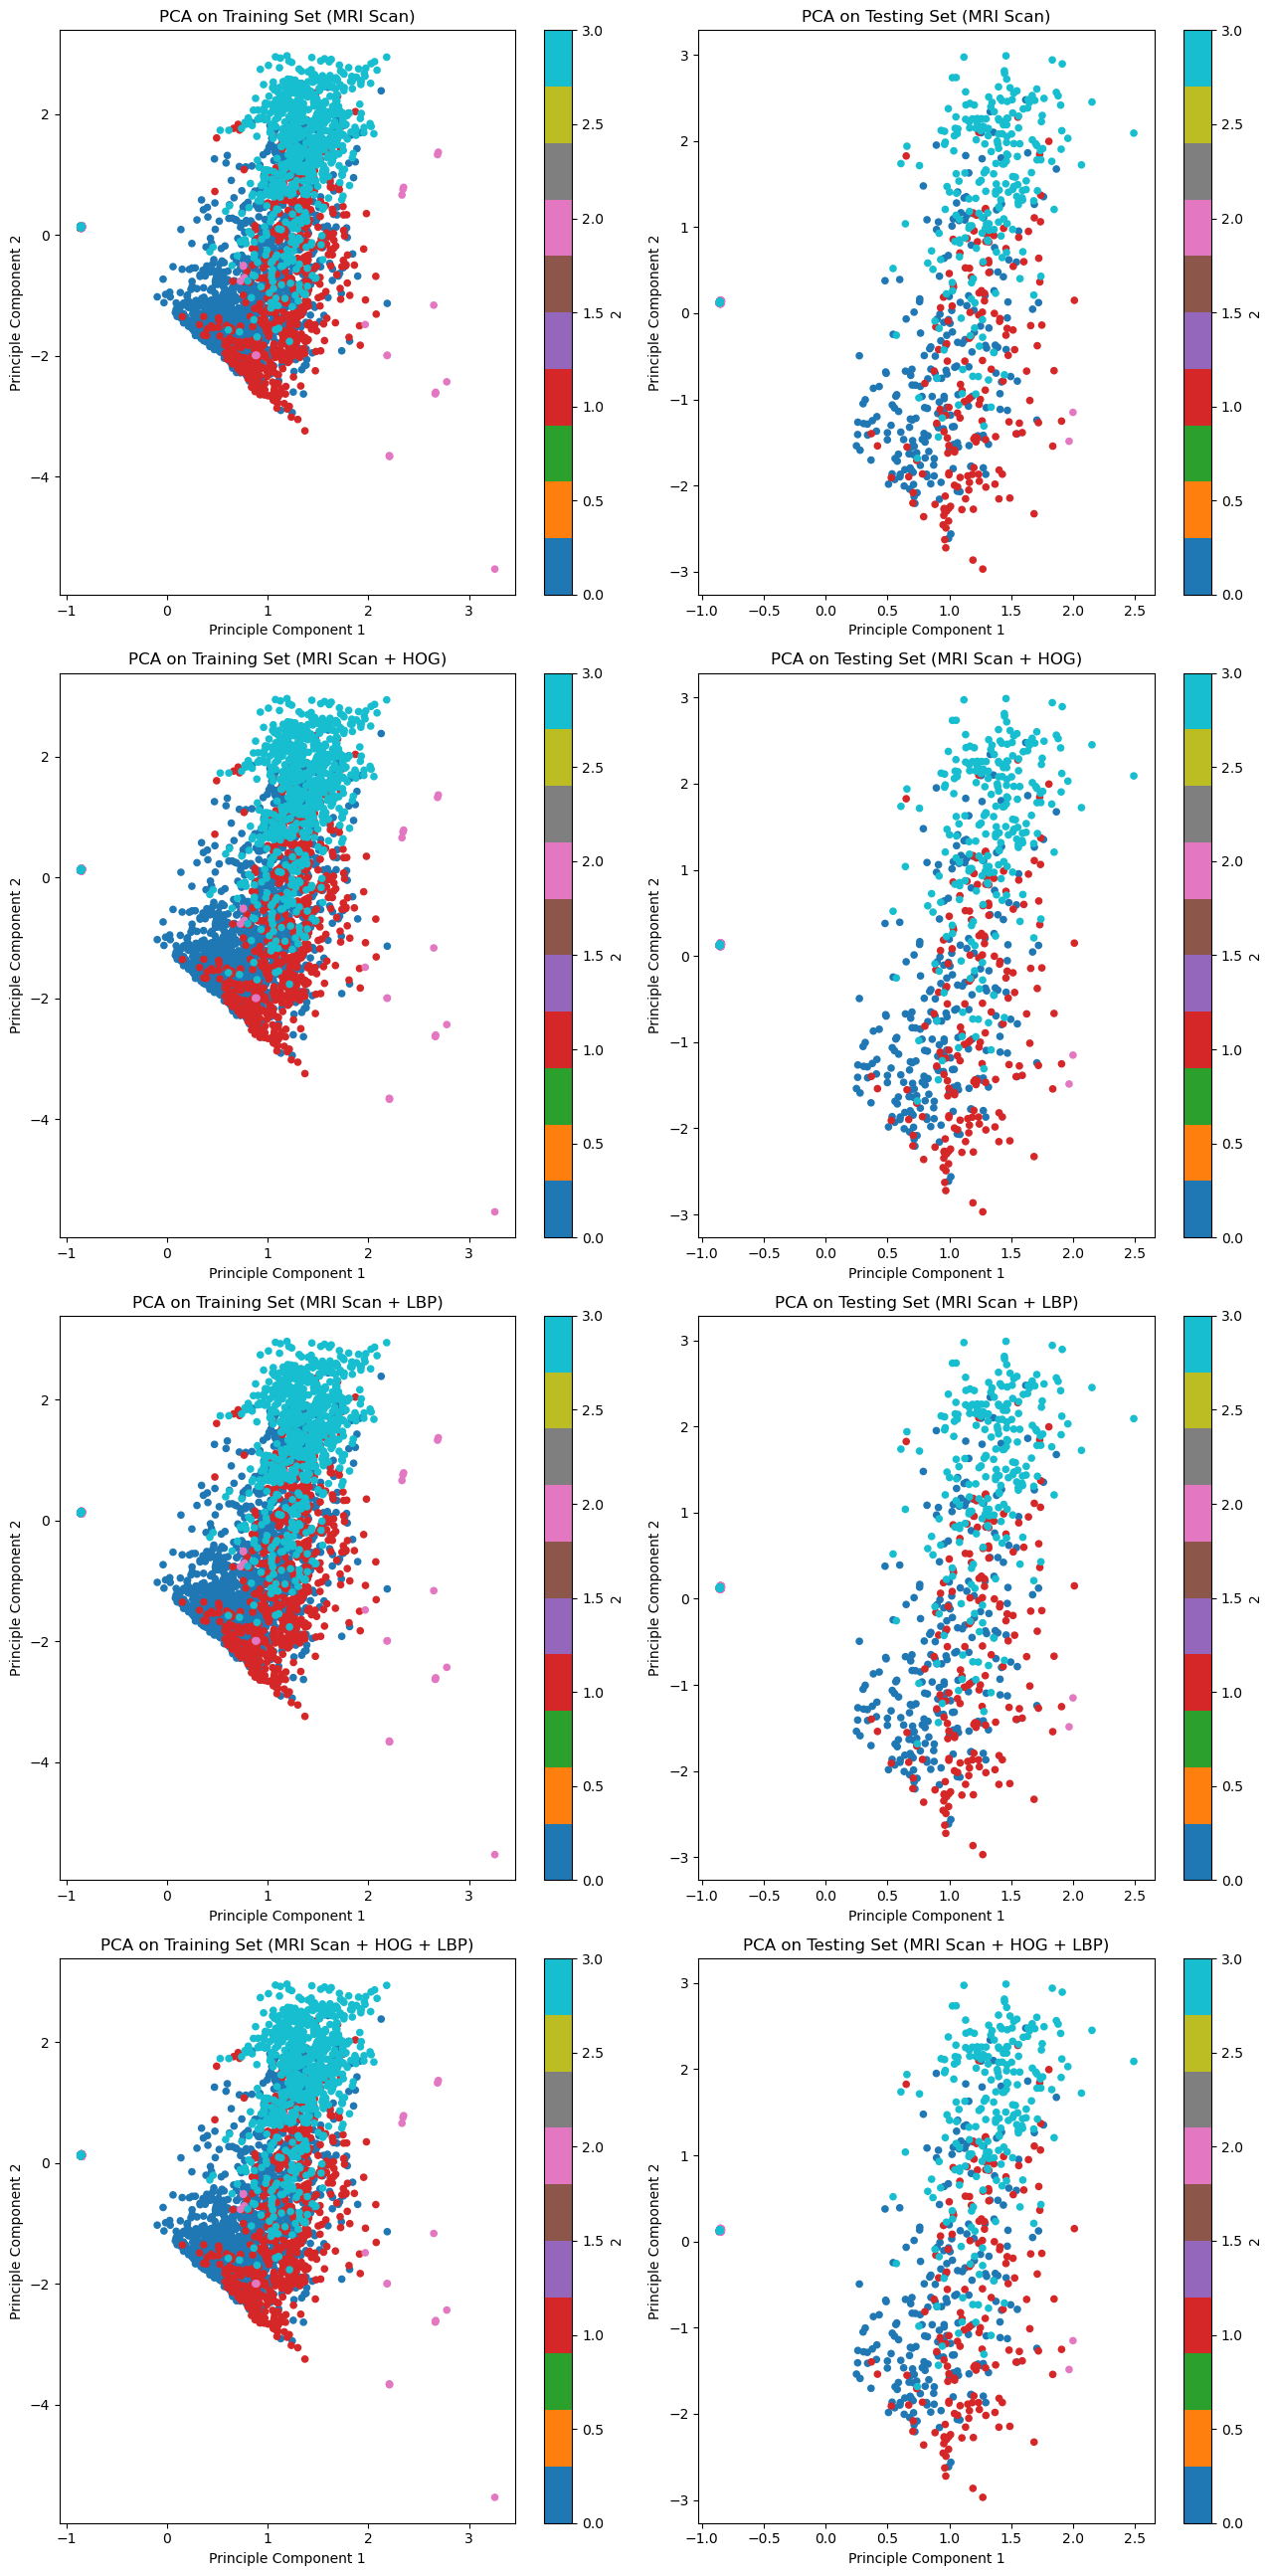

In [46]:
combination = [
  [False, False],
  [True, False],
  [False, True],
  [True, True],
]

fig, axes = plt.subplots(len(combination), 2, figsize=(13, 6.5 * len(combination)))
for index, (hog, lbp) in enumerate(combination):
  train, test = load_brain_tumor_1d(
    include_raw=True, include_hog=hog, include_lbp=lbp, pca_mode="local"
  )
  name_component = ["MRI Scan"]
  if hog:
    name_component.append("HOG")
  if lbp:
    name_component.append("LBP")
  subtitle = f"PCA on {{}} Set ({' + '.join(name_component)})"
  
  pd.DataFrame(train).plot.scatter(
    x=0,
    xlabel="Principle Component 1",
    y=1,
    ylabel="Principle Component 2",
    c=2,
    cmap="tab10",
    vmin=0,
    vmax=3,
    title=subtitle.format("Training"),
    ax=axes[index, 0],
  )
  pd.DataFrame(test).plot.scatter(
    x=0,
    xlabel="Principle Component 1",
    y=1,
    ylabel="Principle Component 2",
    c=2,
    cmap="tab10",
    vmin=0,
    vmax=3,
    title=subtitle.format("Testing"),
    ax=axes[index, 1],
  )

plt.tight_layout()
plt.show()